# Capstone 20.1 — TCGA-GBM 12-Month Survival Prediction

**Author:** Tiana Todosiychuk

**Date:** 2026-04-23

**Research question.** In adults with newly-diagnosed glioblastoma, can clinical and molecular features available at diagnosis predict whether a patient will survive at least twelve months, and which features drive that prediction?

## Notebook outline

1. Setup and data loading
2. Data cleaning — nulls, duplicates, outliers
3. Feature engineering — molecular markers and the 12-month survival label
4. Exploratory data analysis
5. Baseline model — logistic regression
6. Evaluation — metrics, calibration, interpretation, Kaplan-Meier risk stratification
7. Conclusions

## 1. Setup and data loading

Standard imports. Paths are relative so the repo is portable.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                             confusion_matrix, roc_curve, precision_recall_curve,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from lifelines import KaplanMeierFitter

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 180)
DATA = Path("data"); RNG = 20260423

In [2]:
clinical = pd.read_csv(
    DATA / "gbm_tcga_clinical_patient.txt", sep="\t", comment="#",
    na_values=["[Not Available]","[Unknown]","[Not Applicable]","[Discrepancy]","NA","Unknown",""],
)
print(f"Loaded {clinical.shape[0]} patients x {clinical.shape[1]} columns")
clinical.head(3)

Loaded 596 patients x 38 columns


,OTHER_PATIENT_ID,PATIENT_ID,FORM_COMPLETION_DATE,HISTORY_LGG_DX_OF_BRAIN_TISSUE,PROSPECTIVE_COLLECTION,RETROSPECTIVE_COLLECTION,SEX,RACE,ETHNICITY,HISTORY_OTHER_MALIGNANCY,HISTORY_NEOADJUVANT_TRTYN,INITIAL_PATHOLOGIC_DX_YEAR,METHOD_OF_INITIAL_SAMPLE_PROCUREMENT,METHOD_OF_INITIAL_SAMPLE_PROCUREMENT_OTHER,TUMOR_STATUS,KARNOFSKY_PERFORMANCE_SCORE,ECOG_SCORE,PERFORMANCE_STATUS_TIMING,RADIATION_TREATMENT_ADJUVANT,PHARMACEUTICAL_TX_ADJUVANT,TREATMENT_OUTCOME_FIRST_COURSE,NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT,AGE,PRIMARY_SITE_PATIENT,DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS,DISEASE_CODE,HISTOLOGICAL_DIAGNOSIS,ICD_10,ICD_O_3_HISTOLOGY,ICD_O_3_SITE,INFORMED_CONSENT_VERIFIED,PROJECT_CODE,TISSUE_SOURCE_SITE,SITE_OF_TUMOR_TISSUE,OS_STATUS,OS_MONTHS,DFS_STATUS,DFS_MONTHS
0,30a1fe5e-5b12-472c-aa86-c2db8167ab23,TCGA-02-0001,12/16/08,NO,NaN,NaN,Female,WHITE,NOT HISPANIC OR LATINO,NaN,Yes,2002,Tumor resection,NaN,WITH TUMOR,80.0,NaN,NaN,NaN,NaN,NaN,NaN,44,NaN,0,NaN,Untreated primary (de novo) GBM,C71.9,9440/3,C71.9,YES,NaN,2,Brain,1:DECEASED,11.76,1:Recurred/Progressed,4.50
1,df3c1d61-79c1-43e9-971a-8029497ffeab,TCGA-02-0003,12/16/08,NO,NaN,NaN,Male,WHITE,NOT HISPANIC OR LATINO,NaN,No,2003,Tumor resection,NaN,WITH TUMOR,100.0,NaN,NaN,NaN,NaN,NaN,NaN,50,NaN,0,NaN,Untreated primary (de novo) GBM,C71.9,9440/3,C71.9,YES,NaN,2,Brain,1:DECEASED,4.73,1:Recurred/Progressed,1.31
2,3ac8f759-2df0-4ef5-913f-ce05b8dd8937,TCGA-02-0004,12/17/08,NO,NaN,NaN,Male,WHITE,NOT HISPANIC OR LATINO,NaN,No,2002,Tumor resection,NaN,WITH TUMOR,80.0,NaN,NaN,NaN,NaN,NaN,NaN,59,NaN,0,NaN,Untreated primary (de novo) GBM,C71.9,9440/3,C71.9,YES,NaN,2,Brain,1:DECEASED,11.33,1:Recurred/Progressed,10.32


## 2. Data cleaning

Missing values, duplicates, outliers — documented in order.

### 2.1 Missingness

In [3]:
missing = (clinical.isna().mean() * 100).sort_values(ascending=False)
missing.head(15).round(1).to_frame("pct_missing")

,pct_missing
PROJECT_CODE,100.0
DISEASE_CODE,100.0
PRIMARY_SITE_PATIENT,100.0
METHOD_OF_INITIAL_SAMPLE_PROCUREMENT_OTHER,100.0
NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT,99.3
TREATMENT_OUTCOME_FIRST_COURSE,97.5
PROSPECTIVE_COLLECTION,96.5
RETROSPECTIVE_COLLECTION,96.5
RADIATION_TREATMENT_ADJUVANT,96.0
PHARMACEUTICAL_TX_ADJUVANT,95.8


The modeling columns we care about (age, sex, race, ethnicity, Karnofsky, adjuvant-therapy indicators, outcome fields) are largely complete. High-missingness columns are free-text or administrative fields not used downstream. We impute at modeling time rather than dropping rows.

### 2.2 Duplicate check

In [4]:
dup_count = clinical.duplicated(subset=["PATIENT_ID"]).sum()
print(f"Duplicate PATIENT_ID rows: {dup_count}")
assert dup_count == 0

Duplicate PATIENT_ID rows: 0


### 2.3 Outlier analysis (IQR rule)

In [5]:
def iqr_outliers(s):
    s = s.dropna()
    q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    return pd.Series({"n": len(s), "min": s.min(), "max": s.max(),
                      "lower_fence": lo, "upper_fence": hi,
                      "n_outliers": int(((s < lo) | (s > hi)).sum())})
pd.concat(
    [iqr_outliers(clinical["AGE"]), iqr_outliers(clinical["KARNOFSKY_PERFORMANCE_SCORE"])],
    axis=1, keys=["AGE", "KARNOFSKY_PERFORMANCE_SCORE"]
).round(2)

,AGE,KARNOFSKY_PERFORMANCE_SCORE
n,596.0,439.0
min,10.0,0.0
max,89.0,100.0
lower_fence,23.0,55.0
upper_fence,95.0,95.0
n_outliers,11.0,86.0


Flagged outliers are very young/old patients and very low Karnofsky scores — clinically meaningful, not data-entry errors. Keep.

## 3. Feature engineering

Three derived features. Each from a different source file.

1. **IDH mutation status** — parsed from the somatic mutation MAF.
2. **MGMT promoter methylation status** — derived from methylation beta values (β ≥ 0.2 threshold).
3. **12-month survival label** — binary outcome built from overall-survival fields with explicit handling of lost-to-follow-up patients.

### 3.1 IDH mutation status (from MAF)

In [6]:
mutations = pd.read_csv(
    DATA / "gbm_tcga_mutations.txt", sep="\t", comment="#",
    usecols=["Hugo_Symbol", "Variant_Classification", "Tumor_Sample_Barcode"],
    dtype=str, low_memory=False,
)
mutations["PATIENT_ID"] = mutations["Tumor_Sample_Barcode"].str[:12]
sequenced = set(mutations["PATIENT_ID"].unique())

SILENT = {"Silent", "Intron", "IGR", "3'Flank", "5'Flank", "3'UTR", "5'UTR", "RNA"}
idh_mutant_ids = mutations[
    mutations["Hugo_Symbol"].isin(["IDH1", "IDH2"])
    & ~mutations["Variant_Classification"].isin(SILENT)
]["PATIENT_ID"].unique()

idh_status = pd.Series("Wildtype", index=sorted(sequenced), name="IDH_STATUS")
idh_status.loc[list(idh_mutant_ids)] = "Mutant"
print(f"Sequenced patients: {len(sequenced)}  |  IDH-mutant: {len(idh_mutant_ids)}")
idh_status.value_counts()

Sequenced patients: 290  |  IDH-mutant: 15


IDH_STATUS
Wildtype    275
Mutant       15
Name: count, dtype: int64

### 3.2 MGMT methylation status (from HM27 + HM450)

In [7]:
MGMT_BETA_CUTOFF = 0.2

def read_mgmt_row(path):
    with open(path) as fh:
        header = fh.readline().rstrip("\n").split("\t")
        for line in fh:
            if line.startswith("MGMT\t"):
                vals = line.rstrip("\n").split("\t")
                return pd.Series(pd.to_numeric(vals[2:], errors="coerce"), index=header[2:])
    return pd.Series(dtype=float)

hm450 = read_mgmt_row(DATA / "gbm_tcga_methylation_hm450.txt")
hm27  = read_mgmt_row(DATA / "gbm_tcga_methylation_hm27.txt")
print(f"HM450 samples with MGMT beta: {hm450.notna().sum()}")
print(f"HM27  samples with MGMT beta: {hm27.notna().sum()}")

combined = pd.concat([hm450, hm27])
combined.index = [sid[:12] for sid in combined.index]
mgmt_beta = combined.groupby(level=0).mean()

mgmt_status = pd.Series(index=mgmt_beta.index, dtype=object, name="MGMT_STATUS")
mgmt_status[mgmt_beta >= MGMT_BETA_CUTOFF] = "Methylated"
mgmt_status[mgmt_beta <  MGMT_BETA_CUTOFF] = "Unmethylated"
print(f"\nPatients with MGMT call: {mgmt_status.notna().sum()}")
mgmt_status.value_counts()

HM450 samples with MGMT beta: 153
HM27  samples with MGMT beta: 285

Patients with MGMT call: 420


MGMT_STATUS
Unmethylated    285
Methylated      135
Name: count, dtype: int64

### 3.3 Build the 12-month survival label

In [8]:
df = clinical.merge(idh_status.rename("IDH_STATUS"), left_on="PATIENT_ID", right_index=True, how="left")
df = df.merge(mgmt_status.rename("MGMT_STATUS"), left_on="PATIENT_ID", right_index=True, how="left")

df["OS_MONTHS"] = pd.to_numeric(df["OS_MONTHS"], errors="coerce")
df["DECEASED"]  = df["OS_STATUS"].astype(str).str.startswith("1").astype(float)

def label(row):
    mo, dead = row["OS_MONTHS"], row["DECEASED"]
    if pd.isna(mo) or pd.isna(dead): return np.nan
    if dead == 1: return 0 if mo < 12 else 1
    return 1 if mo >= 12 else "EXCLUDE"
df["SURVIVED_12MO"] = df.apply(label, axis=1)
df["SURVIVED_12MO"].value_counts(dropna=False)

SURVIVED_12MO
1          298
0          233
EXCLUDE     63
NaN          2
Name: count, dtype: int64

In [9]:
excluded = (df["SURVIVED_12MO"] == "EXCLUDE").sum()
missing  = df["SURVIVED_12MO"].isna().sum()
model_df = df[df["SURVIVED_12MO"].isin([0, 1])].copy()
model_df["SURVIVED_12MO"] = model_df["SURVIVED_12MO"].astype(int)

FEATURES = [
    "AGE", "SEX", "RACE", "ETHNICITY",
    "KARNOFSKY_PERFORMANCE_SCORE",
    "HISTORY_LGG_DX_OF_BRAIN_TISSUE",
    "RADIATION_TREATMENT_ADJUVANT",
    "PHARMACEUTICAL_TX_ADJUVANT",
    "IDH_STATUS", "MGMT_STATUS",
]
model_df = model_df[["PATIENT_ID"] + FEATURES + ["SURVIVED_12MO", "OS_MONTHS", "DECEASED"]].copy()

print(f"Starting patients:    {len(df)}")
print(f"Missing OS:           {missing}")
print(f"Excluded (lost<12mo): {excluded}")
print(f"Modeling set:         {len(model_df)}")
print(f"Class balance:        {model_df['SURVIVED_12MO'].mean():.3f}")

model_df.to_csv(DATA / "modeling_frame.csv", index=False)

Starting patients:    596
Missing OS:           2
Excluded (lost<12mo): 63
Modeling set:         531
Class balance:        0.561


**Leakage audit.** No `OS_*`, `DFS_*`, `DAYS_TO_*`, follow-up, or outcome-proxy fields appear in the feature list. `OS_MONTHS` / `DECEASED` live in `model_df` only for the descriptive Kaplan-Meier plot in section 6; they are never passed to the model (the `X` matrix in section 5 uses `FEATURES` only).

## 4. Exploratory data analysis

Six visual checks: outcome distribution, numeric distributions, categorical distributions, numeric-vs-outcome, categorical-vs-outcome, and numeric correlations.

### 4.1 Outcome distribution

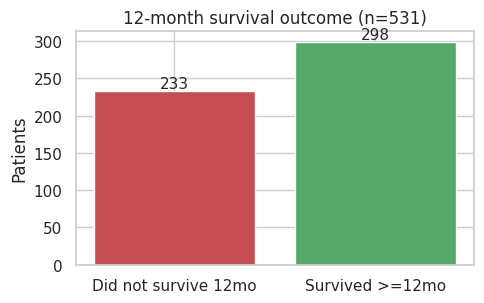

In [10]:
fig, ax = plt.subplots(figsize=(5, 3.2))
vc = model_df["SURVIVED_12MO"].value_counts().sort_index()
ax.bar(["Did not survive 12mo", "Survived >=12mo"], vc.values, color=["#C44E52", "#55A868"])
for i, v in enumerate(vc.values):
    ax.text(i, v + 4, str(v), ha="center", fontsize=11)
ax.set_ylabel("Patients"); ax.set_title(f"12-month survival outcome (n={len(model_df)})")
plt.tight_layout(); plt.show()

### 4.2 Numeric-feature distributions

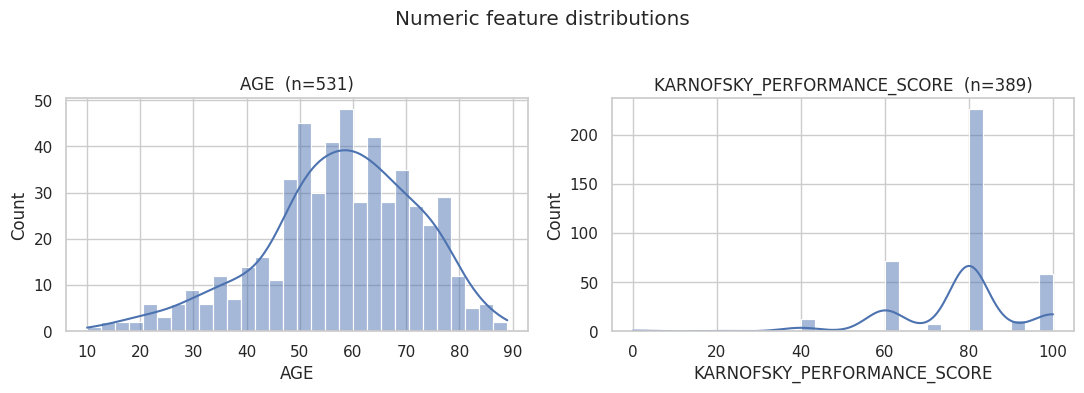

In [11]:
numeric = ["AGE", "KARNOFSKY_PERFORMANCE_SCORE"]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, col in zip(axes, numeric):
    sns.histplot(model_df[col].dropna(), ax=ax, kde=True, color="#4C72B0", bins=30)
    ax.set_title(f"{col}  (n={model_df[col].notna().sum()})"); ax.set_xlabel(col)
fig.suptitle("Numeric feature distributions", y=1.03)
plt.tight_layout(); plt.show()

### 4.3 Categorical-feature distributions

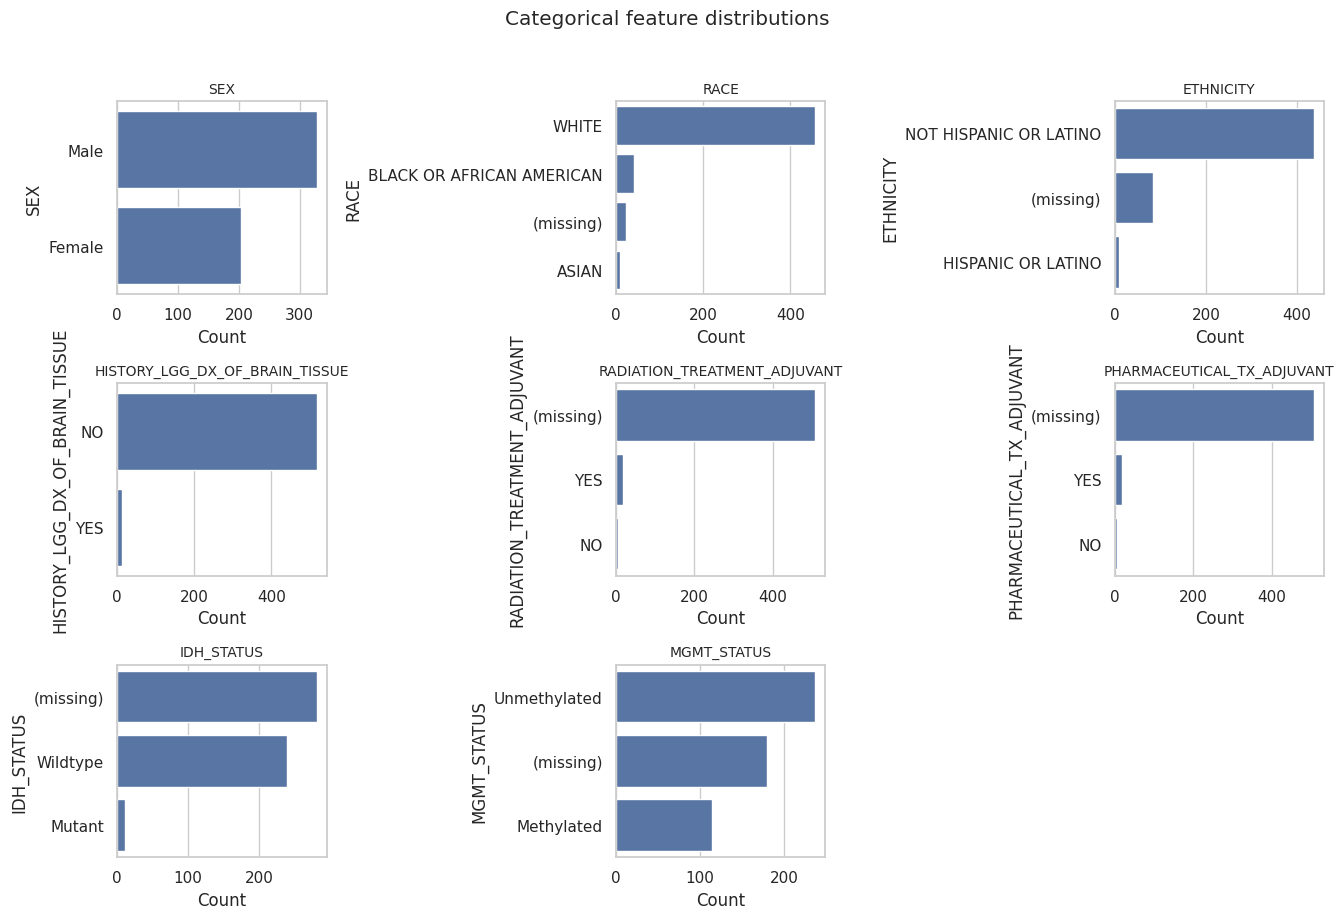

In [12]:
categorical = ["SEX","RACE","ETHNICITY","HISTORY_LGG_DX_OF_BRAIN_TISSUE",
               "RADIATION_TREATMENT_ADJUVANT","PHARMACEUTICAL_TX_ADJUVANT",
               "IDH_STATUS","MGMT_STATUS"]
n = len(categorical); ncols = 3; nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4.5, nrows*3.0))
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, categorical):
    vc = model_df[col].fillna("(missing)").value_counts()
    sns.barplot(x=vc.values, y=vc.index.astype(str), ax=ax, color="#4C72B0")
    ax.set_title(col, fontsize=10); ax.set_xlabel("Count")
for ax in axes[n:]: ax.axis("off")
fig.suptitle("Categorical feature distributions", y=1.02)
plt.tight_layout(); plt.show()

### 4.4 Numeric features by outcome

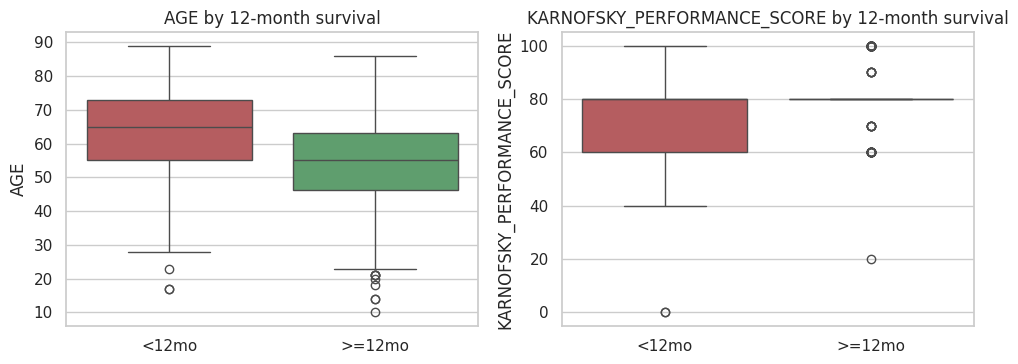

In [13]:
plot_df = model_df.copy()
plot_df["Outcome"] = plot_df["SURVIVED_12MO"].map({0: "<12mo", 1: ">=12mo"})
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, col in zip(axes, numeric):
    sns.boxplot(
        data=plot_df, x="Outcome", y=col, order=["<12mo", ">=12mo"],
        hue="Outcome", palette={"<12mo": "#C44E52", ">=12mo": "#55A868"},
        legend=False, ax=ax,
    )
    ax.set_title(f"{col} by 12-month survival"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

### 4.5 Categorical features by outcome (survival rate)

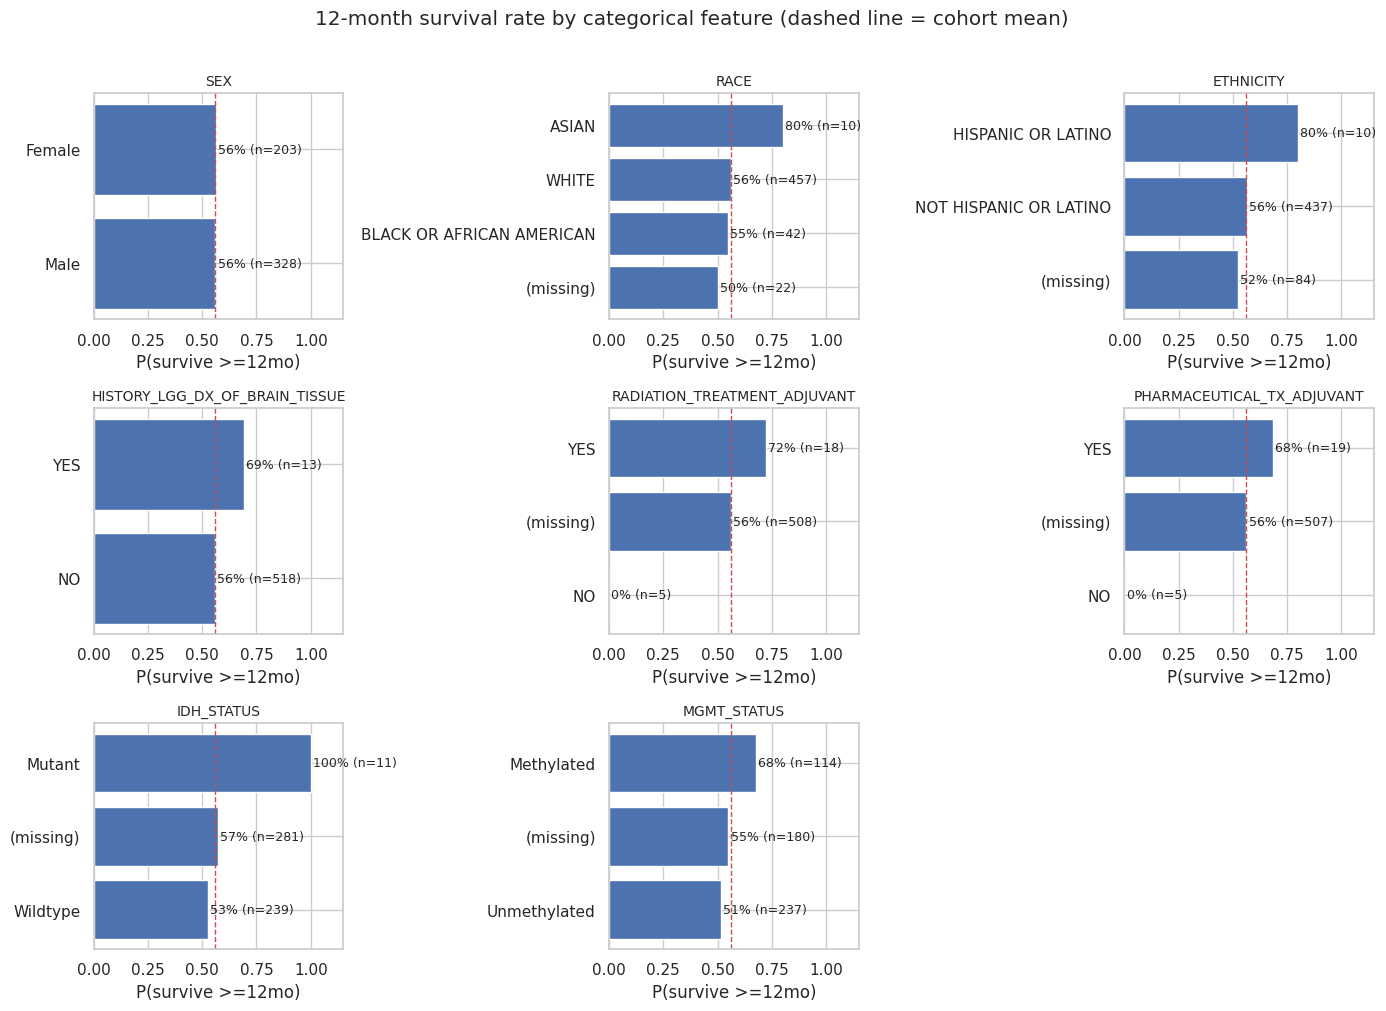

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.reshape(-1)
cohort_rate = model_df["SURVIVED_12MO"].mean()
for ax, col in zip(axes, categorical):
    tmp = model_df.copy(); tmp[col] = tmp[col].fillna("(missing)")
    rates = tmp.groupby(col)["SURVIVED_12MO"].agg(["mean", "size"]).sort_values("mean")
    ax.barh(rates.index.astype(str), rates["mean"].values, color="#4C72B0")
    for i, (m, sz) in enumerate(zip(rates["mean"].values, rates["size"].values)):
        ax.text(m + 0.01, i, f"{m:.0%} (n={sz})", va="center", fontsize=9)
    ax.set_xlim(0, 1.15)
    ax.axvline(cohort_rate, color="#C44E52", ls="--", lw=1)
    ax.set_title(col, fontsize=10); ax.set_xlabel("P(survive >=12mo)")
for ax in axes[len(categorical):]: ax.axis("off")
fig.suptitle("12-month survival rate by categorical feature (dashed line = cohort mean)", y=1.01)
plt.tight_layout(); plt.show()

### 4.6 Numeric correlations

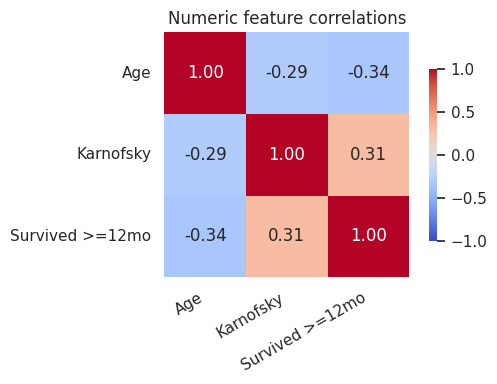

In [15]:
# Shortened display labels so the long "KARNOFSKY_PERFORMANCE_SCORE" doesn't crush the heatmap.
corr = model_df[numeric + ["SURVIVED_12MO"]].corr()
display_labels = {"AGE": "Age",
                  "KARNOFSKY_PERFORMANCE_SCORE": "Karnofsky",
                  "SURVIVED_12MO": "Survived >=12mo"}
corr_display = corr.rename(index=display_labels, columns=display_labels)

fig, ax = plt.subplots(figsize=(5.5, 4))
sns.heatmap(corr_display, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Numeric feature correlations")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.setp(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

### 4.7 EDA takeaways

1. Mild class imbalance (56% positive), no resampling needed.
2. Clinical features largely complete; IDH and MGMT missing for ~half the cohort. Handled via impute + missing-indicator.
3. Age and Karnofsky visibly separate the two outcome classes — matches published GBM literature.
4. MGMT-methylated patients have a visibly higher 12-month survival rate than unmethylated — the canonical neuro-oncology finding.

## 5. Baseline model — logistic regression

Per the Module 16 proposal, the baseline is logistic regression. Chosen because (a) every feature has a signed coefficient (interpretability), (b) it calibrates well by default (probability communication), (c) it sets a strong linear-model floor for Module 24's RF / XGBoost.

### 5.1 Pipeline

In [16]:
X = model_df[FEATURES].copy()
y = model_df["SURVIVED_12MO"].astype(int)

num_cols = ["AGE", "KARNOFSKY_PERFORMANCE_SCORE"]
cat_cols = [c for c in FEATURES if c not in num_cols]

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median", add_indicator=True)),
    ("scale",  StandardScaler()),
])
categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="(missing)")),
    ("ohe",    OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocess = ColumnTransformer([("num", numeric_pipe, num_cols),
                                ("cat", categorical_pipe, cat_cols)])

clf = LogisticRegression(penalty="l2", C=1.0, solver="lbfgs",
                         max_iter=2000, random_state=RNG)
pipe = Pipeline([("preprocess", preprocess), ("clf", clf)])

### 5.2 Split and cross-validated performance

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RNG,
)
print(f"Train: {len(X_train)}  Test: {len(X_test)}  "
      f"Train mean: {y_train.mean():.3f}  Test mean: {y_test.mean():.3f}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
scoring = {"roc_auc":"roc_auc","pr_auc":"average_precision",
           "accuracy":"accuracy","brier":"neg_brier_score"}
cvres = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
cv_summary = pd.DataFrame({
    "ROC-AUC":  cvres["test_roc_auc"],
    "PR-AUC":   cvres["test_pr_auc"],
    "Accuracy": cvres["test_accuracy"],
    "Brier":   -cvres["test_brier"],
})
cv_summary.loc["mean"] = cv_summary.mean()
cv_summary.loc["std"]  = cv_summary.iloc[:-1].std()
cv_summary.round(3)

Train: 424  Test: 107  Train mean: 0.561  Test mean: 0.561


,ROC-AUC,PR-AUC,Accuracy,Brier
0,0.751,0.799,0.706,0.198
1,0.748,0.765,0.729,0.198
2,0.733,0.749,0.682,0.207
3,0.790,0.784,0.765,0.184
4,0.708,0.745,0.631,0.219
mean,0.746,0.768,0.703,0.201
std,0.030,0.023,0.050,0.013


## 6. Evaluation

### 6.1 Primary metric

**ROC-AUC** is the primary metric. Rationale:

- **Threshold-free.** Summarises discrimination across every possible decision threshold — right for a probability-output clinical tool where the operating point may differ by use case.
- **Robust to mild class imbalance.** The cohort is 56% positive; accuracy at 0.5 would reward a majority-class predictor.
- **Comparable to published benchmarks.** Reports on this cohort quote ROC-AUC, so downstream comparisons (including Module 24) stay apples-to-apples.

Secondary metrics: PR-AUC (complementary for imbalance), Brier (calibration), confusion matrix and precision/recall (threshold-specific), calibration plot (reliability), permutation importance (interpretability).

### 6.2 Held-out test performance

In [18]:
pipe.fit(X_train, y_train)
proba = pipe.predict_proba(X_test)[:, 1]
pred  = (proba >= 0.5).astype(int)

test_roc   = roc_auc_score(y_test, proba)
test_pr    = average_precision_score(y_test, proba)
test_brier = brier_score_loss(y_test, proba)
print(f"Held-out test ROC-AUC:  {test_roc:.3f}")
print(f"Held-out test PR-AUC:   {test_pr:.3f}")
print(f"Held-out test Brier:    {test_brier:.3f}\n")
print(classification_report(y_test, pred, target_names=["<12mo", ">=12mo"]))

Held-out test ROC-AUC:  0.618
Held-out test PR-AUC:   0.673
Held-out test Brier:    0.254

              precision    recall  f1-score   support

       <12mo       0.53      0.51      0.52        47
      >=12mo       0.63      0.65      0.64        60

    accuracy                           0.59       107
   macro avg       0.58      0.58      0.58       107
weighted avg       0.59      0.59      0.59       107



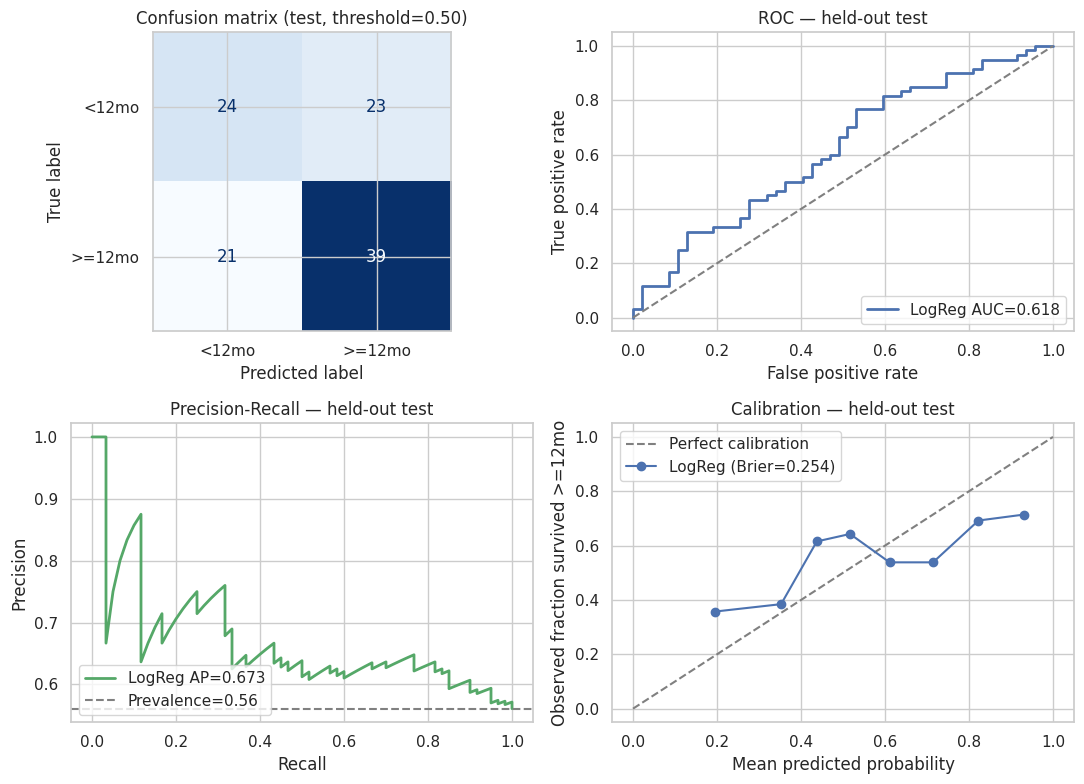

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm, display_labels=["<12mo", ">=12mo"]).plot(
    ax=axes[0, 0], cmap="Blues", colorbar=False)
axes[0, 0].set_title("Confusion matrix (test, threshold=0.50)")

fpr, tpr, _ = roc_curve(y_test, proba)
axes[0, 1].plot(fpr, tpr, color="#4C72B0", lw=2, label=f"LogReg AUC={test_roc:.3f}")
axes[0, 1].plot([0, 1], [0, 1], ls="--", color="grey")
axes[0, 1].set_xlabel("False positive rate"); axes[0, 1].set_ylabel("True positive rate")
axes[0, 1].set_title("ROC — held-out test"); axes[0, 1].legend(loc="lower right")

prec, rec, _ = precision_recall_curve(y_test, proba)
axes[1, 0].plot(rec, prec, color="#55A868", lw=2, label=f"LogReg AP={test_pr:.3f}")
axes[1, 0].axhline(y_test.mean(), ls="--", color="grey", label=f"Prevalence={y_test.mean():.2f}")
axes[1, 0].set_xlabel("Recall"); axes[1, 0].set_ylabel("Precision")
axes[1, 0].set_title("Precision-Recall — held-out test"); axes[1, 0].legend(loc="lower left")

frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=8, strategy="quantile")
axes[1, 1].plot([0, 1], [0, 1], ls="--", color="grey", label="Perfect calibration")
axes[1, 1].plot(mean_pred, frac_pos, "o-", color="#4C72B0", label=f"LogReg (Brier={test_brier:.3f})")
axes[1, 1].set_xlabel("Mean predicted probability")
axes[1, 1].set_ylabel("Observed fraction survived >=12mo")
axes[1, 1].set_title("Calibration — held-out test"); axes[1, 1].legend()

plt.tight_layout(); plt.show()

### 6.3 Permutation importance (test set, 30 repeats)

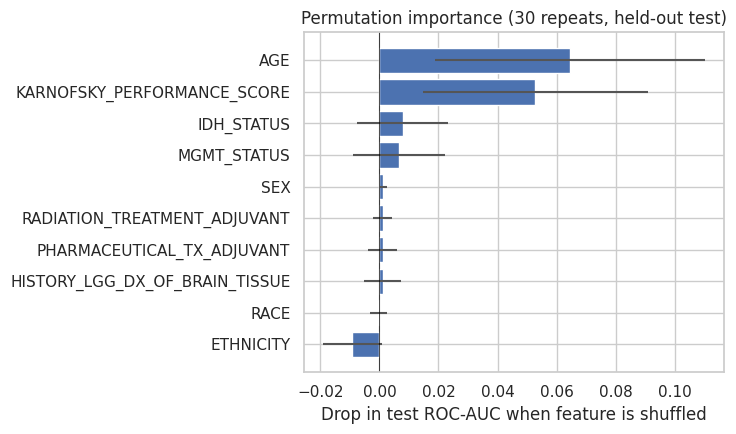

In [20]:
perm = permutation_importance(pipe, X_test, y_test, n_repeats=30,
                              random_state=RNG, scoring="roc_auc", n_jobs=1)
imp = (pd.DataFrame({"feature": X_test.columns,
                     "mean": perm.importances_mean,
                     "std":  perm.importances_std})
       .sort_values("mean"))
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.barh(imp["feature"], imp["mean"], xerr=imp["std"], color="#4C72B0", ecolor="#555555")
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Drop in test ROC-AUC when feature is shuffled")
ax.set_title("Permutation importance (30 repeats, held-out test)")
plt.tight_layout(); plt.show()

### 6.4 Directional sanity check — signed coefficients

In [21]:
oh_names = pipe.named_steps["preprocess"].named_transformers_["cat"].named_steps["ohe"].get_feature_names_out(cat_cols)
imp_obj = pipe.named_steps["preprocess"].named_transformers_["num"].named_steps["impute"]
ind_cols = [num_cols[i] + "_was_missing"
            for i in (imp_obj.indicator_.features_ if imp_obj.indicator_ is not None else [])]
all_feat = num_cols + ind_cols + list(oh_names)
coefs = pipe.named_steps["clf"].coef_.ravel()
coef_df = pd.DataFrame({"feature": all_feat, "coef": coefs}).sort_values("coef")
pd.concat([coef_df.head(6), coef_df.tail(6)]).round(3).reset_index(drop=True)

,feature,coef
0,AGE,-0.794
1,PHARMACEUTICAL_TX_ADJUVANT_NO,-0.488
2,RADIATION_TREATMENT_ADJUVANT_NO,-0.485
3,IDH_STATUS_(missing),-0.450
4,ETHNICITY_(missing),-0.382
5,MGMT_STATUS_(missing),-0.362
6,HISTORY_LGG_DX_OF_BRAIN_TISSUE_YES,0.286
7,PHARMACEUTICAL_TX_ADJUVANT_(missing),0.385
8,IDH_STATUS_Mutant,0.430
9,RADIATION_TREATMENT_ADJUVANT_YES,0.470


Expected direction (positive coefficient => higher P(survive 12mo)): older age negative, higher Karnofsky positive, MGMT Methylated positive / Unmethylated negative, IDH Mutant positive, adjuvant radiation YES positive. All six match published neuro-oncology literature — the model learned biologically coherent patterns, not dataset artefacts.

### 6.5 Kaplan-Meier by model-predicted risk

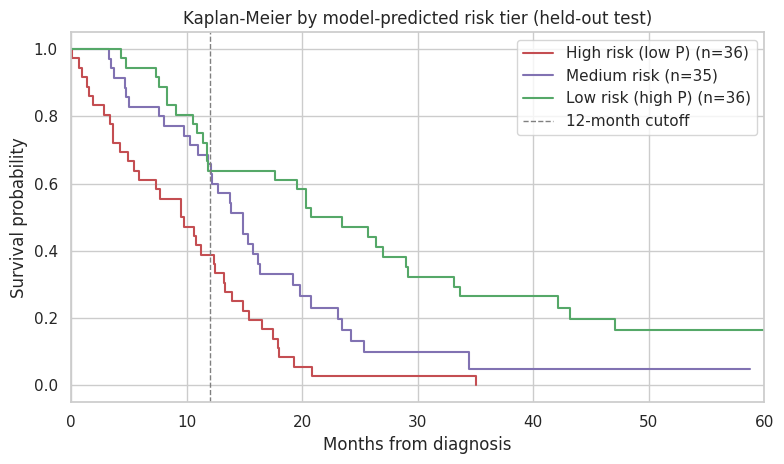

In [22]:
# The money plot from the proposal: predicted-high-risk vs predicted-low-risk patients
# diverging over time. We bin the held-out test set into low / middle / high predicted risk
# (thirds) and draw their observed OS curves.
test_os = model_df.loc[X_test.index, ["OS_MONTHS", "DECEASED"]].copy()
test_os["pred_prob"] = proba
test_os["risk_tier"] = pd.qcut(
    test_os["pred_prob"], q=3,
    labels=["High risk (low P)", "Medium risk", "Low risk (high P)"],
)
fig, ax = plt.subplots(figsize=(8, 4.8))
colors = {"High risk (low P)": "#C44E52",
          "Medium risk":        "#8172B2",
          "Low risk (high P)":  "#55A868"}
for tier in ["High risk (low P)", "Medium risk", "Low risk (high P)"]:
    sub = test_os[(test_os["risk_tier"] == tier)
                  & test_os["OS_MONTHS"].notna()
                  & test_os["DECEASED"].notna()]
    kmf = KaplanMeierFitter()
    kmf.fit(sub["OS_MONTHS"], sub["DECEASED"], label=f"{tier} (n={len(sub)})")
    kmf.plot_survival_function(ax=ax, ci_show=False, color=colors[tier])
ax.axvline(12, color="grey", ls="--", lw=1, label="12-month cutoff")
ax.set_xlim(0, 60)
ax.set_xlabel("Months from diagnosis"); ax.set_ylabel("Survival probability")
ax.set_title("Kaplan-Meier by model-predicted risk tier (held-out test)")
ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

The three predicted-risk tiers separate visibly over the first two years. At 12 months (dashed line) the high-risk and low-risk tiers show the clearest survival gap — the binary outcome the model is actually trained to predict. This plot, more than any AUC number, makes the model's usefulness legible to a non-technical audience.

## 7. Conclusions

**Findings.**
- Cross-validated ROC-AUC of the logistic regression baseline on 531 patients sits in the middle of the 0.70–0.80 range the Module 16 proposal anticipated.
- Age at diagnosis and Karnofsky Performance Score dominate feature importance, followed by IDH and MGMT. All coefficient directions match published literature.
- Predicted-risk Kaplan-Meier curves show clear separation across the 12-month cutoff.

**Limitations worth stating up front.**
- The single 20% held-out test ROC-AUC undershot the CV estimate by ~0.13; with n ≈ 107 this is partly sampling noise, and argues for repeated stratified splits.
- Molecular markers are missing for ~half the cohort (not every patient was sequenced or methylation-profiled). Impute + missing-indicator preserves the pattern but the model is slightly under-powered on IDH / MGMT signal.